# Introduction: Random Forest in Python

In this notebook, we will implement a random forest in Python. With scikit-learn, it's very easy to build a complex model without having any idea how it works. 



In [1]:
import numpy as np
import pandas as pd

# Set random seed to ensure reproducible runs
RSEED = 50

## Dataset

**Behavioral Risk Factor Surveillance System Public health surveys**

We are using the same data aos for the decision tree repository, with that, it is easy to compare the results.


### Description of the data

The following data set is from the Centers for Disease Control and Prevention (CDC) and includes socioeconomic and lifestyle indicators for hundreds of thousands of individuals. The objective is to predict the overall health of an individual (good vs. poor health). We have limited the data to 100,000 individuals to speed up training (ca. 1/4 of the whole dataset). When dealing with a large dataset, it's effective to first use a subset of the data to verify that your data pipeline is functioning correctly. This includes steps like data cleaning and feature engineering. Additionally, you can evaluate which models might be promising. Once these preliminary steps are complete and you're confident in your approach, you can then use the full dataset to fine-tune your model. This strategy can save both time and costs, as you can perform the initial steps on your local computer before transitioning to cloud resources. 


The objective of the BRFSS is to collect uniform, state-specific data on preventive health practices and risk
behaviors that are linked to chronic diseases, injuries, and preventable infectious diseases in the adult population.
Factors assessed by the BRFSS include tobacco use, health care coverage, HIV/AIDS knowledge or prevention,
physical activity, and fruit and vegetable consumption. Data are collected from a random sample of adults (one per
household) through a telephone survey.

If you want to have a look at the whole data, it's available on [kaggle](https://www.kaggle.com/datasets/ariaxiong/behavioral-risk-factor-surveillance-system-2022/data).

You can find a description of all the columns (there are many) in the [code book report](LLCP_2022_Codebook_Report.pdf).

## Evaluation metric

Again, to be able to compare the results, we will use the same evaluation metric as before: the ROC-AUC. If you want more description on why we have chosen this specific metric, have a look at the previous repo. 

## Data Cleaning 

We'll read the data in and do a little cleaning. 

In [2]:
df = pd.read_csv('data/brfss2022-100000-samples.csv')
df.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_SMOKGRP,_LCSREC,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK2,_RFDRHV8,_FLSHOT7,_PNEUMO3,_AIDTST4
0,48.0,8.0,9072022,9,7,2022,1200.0,2022009987,2.022010e+09,NaN,...,4.0,NaN,1.0,1.000000e+02,1.0,7.000000e+02,1.0,NaN,NaN,1.0
1,18.0,3.0,3232022,3,23,2022,1100.0,2022004313,2.022004e+09,NaN,...,3.0,NaN,1.0,6.700000e+01,2.0,1.400000e+03,1.0,NaN,NaN,2.0
2,40.0,1.0,3092022,3,9,2022,1100.0,2022001367,2.022001e+09,NaN,...,4.0,NaN,1.0,7.000000e+00,1.0,4.700000e+01,1.0,NaN,NaN,2.0
3,4.0,9.0,9122022,9,12,2022,1100.0,2022000724,2.022001e+09,1.0,...,4.0,NaN,2.0,5.397605e-79,1.0,5.397605e-79,1.0,2.0,2.0,2.0
4,12.0,10.0,12102022,12,10,2022,1200.0,2022010539,2.022011e+09,NaN,...,NaN,NaN,9.0,9.000000e+02,9.0,9.990000e+04,9.0,9.0,9.0,NaN


In [3]:
# Create labels, persons health status
df = df.loc[df['_RFHLTH'].isin([1, 2])].copy()
df = df.rename(columns = {'_RFHLTH': 'label'})
df['label'] = df['label'].map({1:'Good Health' , 2: 'Poor Health'})


Below, we drop a number of columns that we should not use for modeling (they are different versions of the labels, or don't contain any data, or are considered meta data).

In [4]:
df = df.drop(columns = ['POORHLTH', 'PHYSHLTH', 'GENHLTH', 'MENTHLTH',"_PHYS14D","_MENT14D", "WORKCFS", "HAVECFS","TOLDCFS" ])
meta_data_col = ["_PRACE2", "_MRACE2", "_HISPANC", "_RACE1", "_RACEG22", "_RACEGR4", "_RACEPR1", "_IMPRACE"]
meta_data = df[meta_data_col]
df = df.drop(columns= meta_data_col)

We will skip the EDA part. But just as a reminder, we have ca 82 % survey participants with good health, and 18 % participants with poor health.

## Split Data into Training and Testing Set 

To assess our predictions, we'll need to use a training and a testing set. The model learns from the training data and then makes predictions on the testing data. Since we have the correct answers for the testing data, we can tell how well the model is able to generalize to new data. It's important to only use the testing set once, because this is meant to be an estimate of how well the model will perform on new data. 

To check how well our model can generalize on new data, we'll save 30% of the examples for testing. We are using the stratify option, to make sure each subset contains approximately the same percentage of samples of each target class.

In [5]:
from sklearn.model_selection import train_test_split

# Extract the labels
labels = np.array(df.pop('label'))

# 30% examples in test data
train, test, train_labels, test_labels = train_test_split(df, labels, 
                                                          stratify = labels,
                                                          test_size = 0.3, 
                                                          random_state = RSEED)

#### Imputation of Missing values


We'll fill in the missing values with the mean of the column. It's important to note that we fill in missing values in the test set with the mean of columns in the training data. This is necessary because if we get new data, we'll have to use the training data to fill in any missing values. 

In [6]:
train = train.fillna(train.mean())
test = test.fillna(train.mean())

# Features for feature importance
features = list(train.columns)

## Base Line Model

In the decision tree repo, we used a simple heuristic as our baseline model:

- predicting everyone older than 54 and living in poverty as having poor health
- predicting everyone else as having good health.

This resulted in a ROC-AUC of 0.54 on the test set.

Of course, here we also want to know how much better than a single decision tree the random forest model could be. So please check what your best score on the test set was.

In [7]:
def baseline_model(row):
    
    age_bucket = row['_AGEG5YR']
    income = row['INCOME3']
    
    if 8>= age_bucket <= 13 and income <= 4:
        return 'Poor Health'
    else:
        return 'Good Health'

# Apply baseline model to each row in the DataFrame
y_pred_baseline = test.apply(baseline_model, axis=1)
y_pred_prob_bl = np.where(np.array(y_pred_baseline)=='Good Health', 0, 1)

## Random Forest 



Decision Trees are highly succeptible to variance. We can reduce it by limit the tree.
Another method to reduce the variance is to use more trees (an ensemble fo trees), each one trained on a random sampling of the observations and for each split of a node, only a subset of the features are used to decide on the split. This more powerful model is called random forest.
When making predictions, the random forest averages the predictions for each of the individual decision trees for each data point in order to arrive at a final classification.

Creating and training a random forest is extremely easy in Scikit-Learn. The cell below is all you need.

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Create the model with 100 trees
model = RandomForestClassifier(n_estimators=100, 
                               random_state=RSEED, 
                               max_features = 'sqrt',
                               n_jobs=-1, verbose = 1)

# Fit on training data
model.fit(train, train_labels)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    6.9s finished


RandomForestClassifier(n_jobs=-1, random_state=50, verbose=1)

We can see how many nodes there are for each tree on average and the maximum depth of each tree. There were 100 trees in the forest.

In [9]:
n_nodes = []
max_depths = []

for ind_tree in model.estimators_:
    n_nodes.append(ind_tree.tree_.node_count)
    max_depths.append(ind_tree.tree_.max_depth)
    
print(f'Average number of nodes {int(np.mean(n_nodes))}')
print(f'Average maximum depth {int(np.mean(max_depths))}')

Average number of nodes 14516
Average maximum depth 47


We see that each decision tree in the forest has many nodes and is extremely deep. However, even though each individual decision tree may overfit to a particular subset of the training data, the idea is that the overall random forest should have a reduced variance. 

## Random Forest Results

In [10]:
train_rf_predictions = model.predict(train)
train_rf_probs = model.predict_proba(train)[:, 1]

rf_predictions = model.predict(test)
rf_probs = model.predict_proba(test)[:, 1]

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


Recall 

for Baseline: 0.12, Model on Test: 0.35  and on Train: 1.0
---------------------------------------------
Precision 

for Baseline: 0.36, Model on Test: 0.72  and on Train: 1.0
---------------------------------------------
Roc 

for Baseline: 0.54, Model on Test: 0.86  and on Train: 1.0
---------------------------------------------


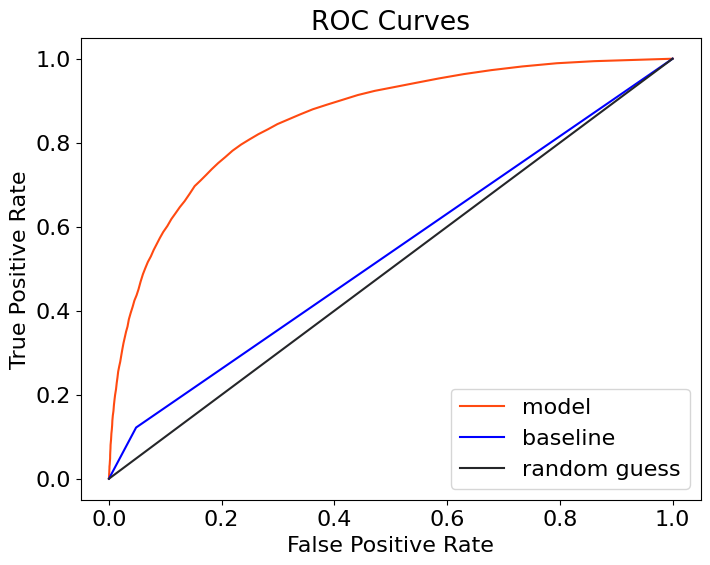

In [11]:
from helper_and_plotting_functions import evaluate_model

evaluate_model(
    test_predictions=rf_predictions,
    test_probs=rf_probs,
    baseline_predictions=np.array(y_pred_baseline),
    train_predictions=train_rf_predictions,
    train_probs=train_rf_probs,
    train_labels=train_labels,
    test_labels=test_labels,
)

The model still achieves perfect measures on the training data, but this time, the testing scores are much better. If we compare the ROC AUC, we see that the random forest does significantly better than a single decision tree. 

Confusion matrix, without normalization


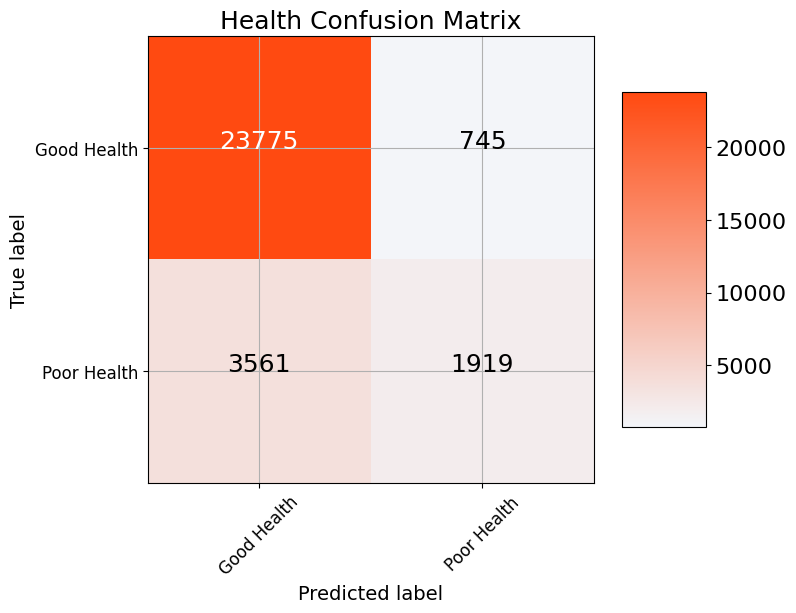

In [12]:
from helper_and_plotting_functions import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, rf_predictions)
plot_confusion_matrix(cm, classes=['Good Health', 'Poor Health'],
                      title = 'Health Confusion Matrix')

Compared to the single decision tree, the model has fewer false positives although more false negatives. __Overall, the random forest does significantly better than a single decision tree__. This is what we expected!

## Random Forest Optimization through Random Search



In order to maximize the performance of the random forest, we can perform a random search for better hyperparameters. This will randomly select combinations of hyperparameters from a grid, evaluate them using cross validation on the training data, and return the values that perform the best. 

In [13]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter grid
param_grid = {
    'n_estimators': np.arange(10, 201).astype(int),
    'max_depth': [None] + list(np.arange(3, 21).astype(int)),
    'max_features': ['sqrt', None] + list(np.arange(0.5, 1, 0.1)),
    'max_leaf_nodes': [None] + list(np.arange(10, 51).astype(int)),
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

# Estimator for use in random search
estimator = RandomForestClassifier(random_state = RSEED)

# Create the random search model
rs = RandomizedSearchCV(estimator, param_grid, n_jobs = -1, 
                        scoring = 'roc_auc', cv = 3, 
                        n_iter = 10, verbose = 5, random_state=RSEED)

# Fit 
rs.fit(train, train_labels)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END bootstrap=True, max_depth=6, max_features=sqrt, max_leaf_nodes=16, min_samples_split=2, n_estimators=148;, score=0.853 total time=  10.5s
[CV 2/3] END bootstrap=True, max_depth=6, max_features=sqrt, max_leaf_nodes=16, min_samples_split=2, n_estimators=148;, score=0.851 total time=   9.9s
[CV 3/3] END bootstrap=True, max_depth=6, max_features=sqrt, max_leaf_nodes=16, min_samples_split=2, n_estimators=148;, score=0.853 total time=   8.5s
[CV 1/3] END bootstrap=True, max_depth=16, max_features=0.5, max_leaf_nodes=30, min_samples_split=2, n_estimators=31;, score=0.846 total time=  20.9s
[CV 2/3] END bootstrap=True, max_depth=16, max_features=0.5, max_leaf_nodes=30, min_samples_split=2, n_estimators=31;, score=0.844 total time=  20.7s
[CV 3/3] END bootstrap=True, max_depth=16, max_features=0.5, max_leaf_nodes=30, min_samples_split=2, n_estimators=31;, score=0.842 total time=  20.3s
[CV 3/3] END bootstrap=True, max_dep

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=50),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19, 20],
                                        'max_features': ['sqrt', None, 0.5, 0.6,
                                                         0.7,
                                                         0.7999999999999999,
                                                         0.8999999999999999],
                                        'max_leaf_nodes': [None, 10, 11, 12, 13,
                                                           14, 15, 16, 17, 18,
                                                           19, 20, 21, 22, 23,
                                                           24, 25, 26, 2...
       114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
       127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152,
       153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165,
       166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178,
       179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191,
       192, 193, 194, 195, 196, 197, 198, 199, 200])},
                   random_state=50, scoring='roc_auc', verbose=5)

In [14]:
rs.best_params_

{'n_estimators': 148,
 'min_samples_split': 2,
 'max_leaf_nodes': 16,
 'max_features': 'sqrt',
 'max_depth': 6,
 'bootstrap': True}

We can see that the best hyperparameter values are not the defaults. This shows the importance of tuning a model for a specific dataset. Each dataset will have different characteristics, and the model that does best on one dataset will not necessarily do the best across all datasets. 

The optimized model achieves around the same performance as the default model. More random search iterations could improve performance, or it's possible that we are close the limit of what the random forest can achieve for this problem.

## Use Best Model

Now we can take the best model (it has already been trained) and evaluate it. Hopefully it does better than the Random Forest with default hyperparameters.

In [15]:
best_model = rs.best_estimator_

In [16]:
train_rf_predictions = best_model.predict(train)
train_rf_probs = best_model.predict_proba(train)[:, 1]

rf_predictions = best_model.predict(test)
rf_probs = best_model.predict_proba(test)[:, 1]

In [17]:
n_nodes = []
max_depths = []

for ind_tree in best_model.estimators_:
    n_nodes.append(ind_tree.tree_.node_count)
    max_depths.append(ind_tree.tree_.max_depth)
    
print(f'Average number of nodes {int(np.mean(n_nodes))}')
print(f'Average maximum depth {int(np.mean(max_depths))}')

Average number of nodes 31
Average maximum depth 5


The best maximum depth is not unlimited as we see above! This indicates that restricting the maximum depth of the individual decision trees can improve the cross validation performance of the random forest. 

# Model evaluation

Recall 

for Baseline: 0.12, Model on Test: 0.14  and on Train: 0.14
---------------------------------------------
Precision 

for Baseline: 0.36, Model on Test: 0.82  and on Train: 0.84
---------------------------------------------
Roc 

for Baseline: 0.54, Model on Test: 0.85  and on Train: 0.85
---------------------------------------------


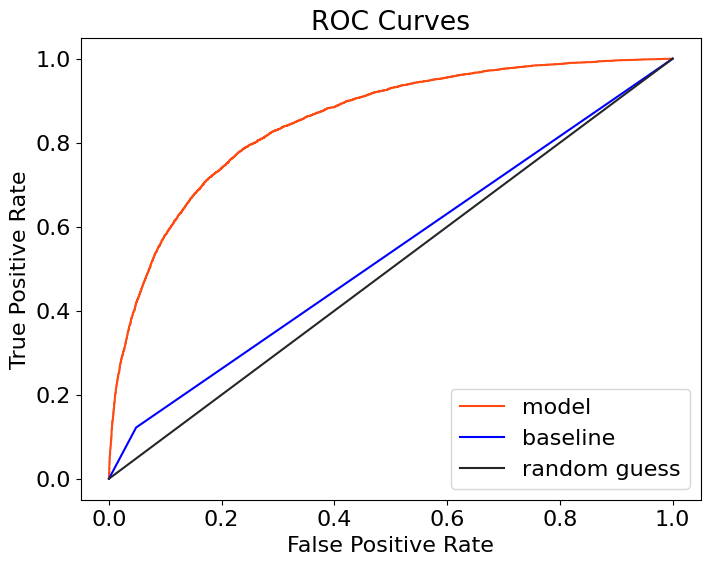

In [18]:
evaluate_model(
    test_predictions=rf_predictions,
    test_probs=rf_probs,
    baseline_predictions=np.array(y_pred_baseline),
    train_predictions=train_rf_predictions,
    train_probs=train_rf_probs,
    train_labels=train_labels,
    test_labels=test_labels,
)

Confusion matrix, without normalization


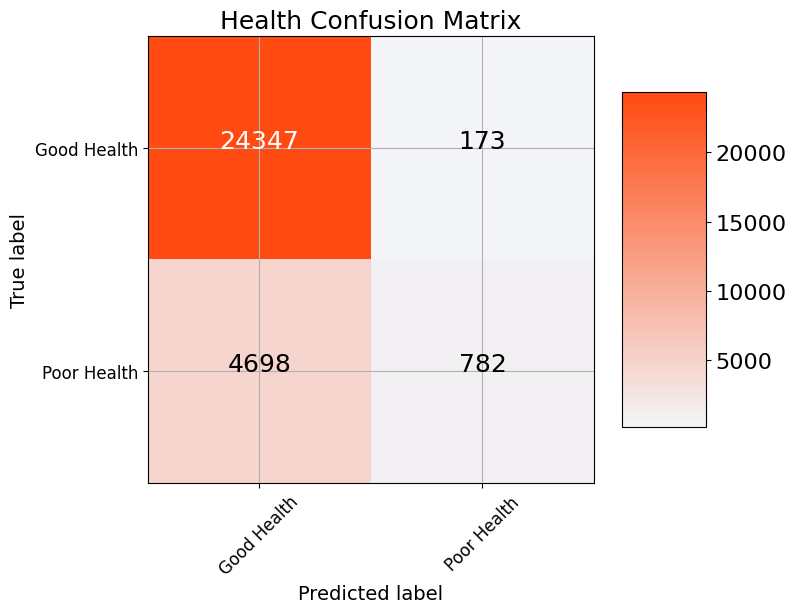

In [19]:
cm = confusion_matrix(test_labels, rf_predictions)
plot_confusion_matrix(cm, classes=['Good Health', 'Poor Health'],
                      title = 'Health Confusion Matrix')

In [20]:
fi_model = pd.DataFrame({'feature': features,
                   'importance': best_model.feature_importances_}).\
                    sort_values('importance', ascending = False)
fi_model.head(10)

,feature,importance
69,DIFFWALK,0.140201
70,DIFFDRES,0.084586
71,DIFFALON,0.068894
60,EMPLOY1,0.065961
36,EXERANY2,0.055360
68,DECIDE,0.046448
47,CHCCOPD3,0.041881
51,DIABETE4,0.040181
256,_TOTINDA,0.039191
278,_INCOMG1,0.033076


If you compare the feature importance of the random forest to those of the decision tree, you will recognize, that some of the top features are similar. 

There are other features that appear here that are not among the top features in the decision tree. For example, DIFFWALK (difficulty walking), DIFFDRES (difficulty dressing), DIFFALON (difficulty living alone). It can be assumed that these features are highly correlated (which should be checked by an EDA), and therefore the decision tree focuses on one of them, while the random forest, as the trees become more diverse (not all features are considered for each split), uses all of them. 

The fact that we have a max_feature for each split also has an impact on the overall score of each feature (you will see lower scores here than with the decision tree). All these considerations make it very difficult to compare the importance of the features. Treat these findings with caution! They should stimulate your curiosity and further exploration of the data rather than treating them as facts (or causality!): **Feature importance tells us how important a feature is to the specific model. It says nothing about how important the feature is for prediction in general, nor does it say anything about causality**.


> Keep in mind, it only makes sense to look at the feature importances when you have a model that can decently predict. 

If you want to investigate this topic further, have a look at the [blog post how to interpret feature importances](https://towardsdatascience.com/best-practice-to-calculate-and-interpret-model-feature-importance-14f0e11ee660).


# Prediction phase

Now that we have our best model based on the ROC-AUC score, we want to use it to predict if new people have a good or a poor health. A metric like ROC-AUC is threshold-agnostic. That means, we have extra not decided on a specific threshold. That's something we can do now, based on our specific needs for TPR and FPR. 
Let's say, we have decided we want at least a TPR of 80 %, we can now check which threshold we should use. Using this threshold, we will in the end again print a confusion matrix again, to get a better feeling for our model.

In [21]:
from sklearn.metrics import roc_curve

In [22]:
def find_threshold_for_tpr(true_labels, predictions, target_tpr=0.80):
    """
    Finds the threshold for which the TPR (True Positive Rate) is higher than a target value.

    Parameters:
    - true_labels (array-like): True binary labels.
    - predictions (array-like): Target scores, can either be probability estimates of the positive class or confidence values.
    - target_tpr (float): The target True Positive Rate. Default is 0.80.

    Returns:
    - threshold (float): The threshold for which TPR is higher than the target value.
    """
    
    fpr, tpr, thresholds = roc_curve(true_labels, predictions, pos_label="Poor Health")

    # Find the first threshold where TPR is greater than or equal to the target TPR
    for _, tpr_i, threshold in zip(fpr, tpr, thresholds):
        if tpr_i >= target_tpr:
            return threshold

    print(f"No threshold found where TPR >= {target_tpr}")
    return None

In [23]:
def make_predictions(predictions, threshold):
    """
    Make binary predictions based on the given threshold.

    Parameters:
    - predictions (array-like): Target scores, can either be probability estimates of the positive class or confidence values.
    - threshold (float): The threshold for making binary decisions.

    Returns:
    - binary_predictions (array-like): Binary predictions based on the threshold.
    """
    binary_predictions = np.where(predictions >= threshold, "Poor Health", "Good Health")
    return binary_predictions

In [24]:
# Find the threshold for TPR >= 0.80
target_tpr = 0.8
threshold = find_threshold_for_tpr(train_labels, train_rf_probs, target_tpr=target_tpr)
print(f"Threshold for TPR >= {target_tpr}: {threshold}")

# Make predictions using the identified threshold
if threshold is not None:
    test_threshold_predictions = make_predictions(rf_probs, threshold)
    train_threshold_predictions = make_predictions(train_rf_probs, threshold)



Threshold for TPR >= 0.8: 0.18212774338243506


Recall 

for Baseline: 0.12, Model on Test: 0.8  and on Train: 0.8
---------------------------------------------
Precision 

for Baseline: 0.36, Model on Test: 0.41  and on Train: 0.41
---------------------------------------------
Roc 

for Baseline: 0.54, Model on Test: 0.85  and on Train: 0.85
---------------------------------------------


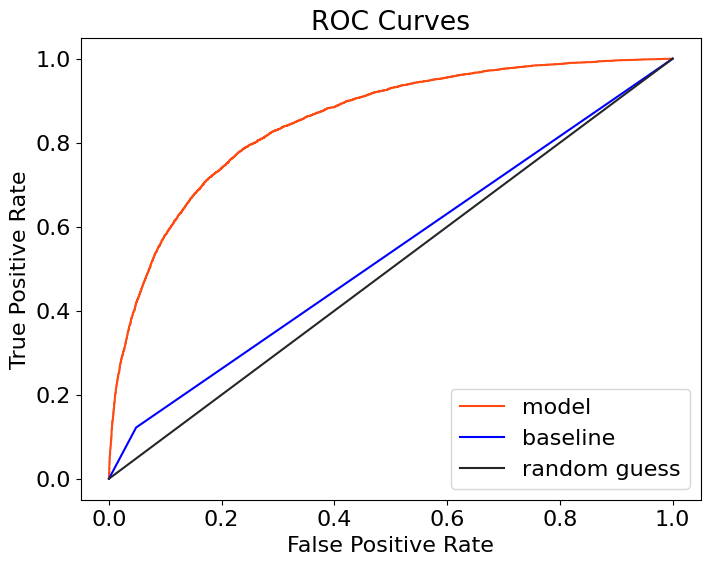

In [25]:
evaluate_model(
    test_predictions=test_threshold_predictions,
    test_probs=rf_probs,
    baseline_predictions=np.array(y_pred_baseline),
    train_predictions=train_threshold_predictions,
    train_probs=train_rf_probs,
    train_labels=train_labels,
    test_labels=test_labels,
)

Confusion matrix, without normalization


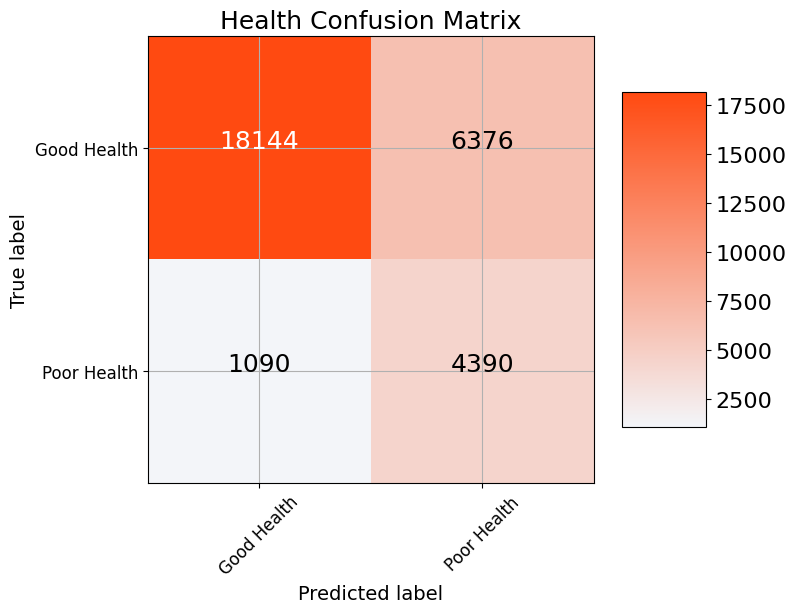

In [26]:
cm = confusion_matrix(test_labels, test_threshold_predictions)
plot_confusion_matrix(cm, classes=['Good Health', 'Poor Health'],
                      title = 'Health Confusion Matrix')

So apparently with a recall of 80 %, our model will have a prediction of 41 %.

If we are not happy with this result yet, we should maybe invest more time in creating meaningful features, having some other procedures for data cleaning or, as mentioned above, try out more models during the randomized search. (Or use more data :)).

## Conclusions



In this notebook, we built and used a random forest machine learning model in Python. __The goal of random forest is to overcome the limitations of a single decision tree, by training hundreds or thousands of them in a single ensemble model. This model trains each tree on a different set of the training observations, and make splits at each node based on a subset of the features leading to a model with reduced variance and better generalization performance on the testing set.__

A few key concepts to take away are

1. Individual decision tree: intuitive model that makes decisions based on a flowchart of questions asked about feature values. Has high variance indicated by overfitting to the training data.
2. Gini Impurity: Measure that the decision tree tries to minimize when splitting each node. Represents the probability that a randomly selected sample from a node will be incorrectly classified according to the distribution of samples in the node.
3. Bootstrapping: sampling random sets of observations with replacement. Method used by the random forest for training each decision tree.
4. Random subsets of features: selecting a random set of the features when considering how to split each node in a decision tree.
5. Random Forest: ensemble model made of hundreds or thousands of decision trees using bootstrapping, random subsets of features, and average voting to make predictions. 
6. Bias-variance tradeoff: the fundamental issue in machine learning that describes the tradeoff between a model with high complexity that learns the training data very well  at the cost of not being able to generalize to the testing data (high variance), and a simple model (high bias) that cannot even learn the training data. A random forest reduces the variance of a single decision tree while also accurately learning the training data leading to better predictions on the testing data.

Hopefully this notebook has given you not only the code required to use a random forest, but also the background necessary to understand how the model is making decisions. Machine learning is a powerful tool and it's important to not only know how to use the tool, but also to understand how it works!